# Computer Vision Nanodegree

## Project: Image Captioning

---

The Microsoft **C**ommon **O**bjects in **CO**ntext (MS COCO) dataset is a large-scale dataset for scene understanding.  The dataset is commonly used to train and benchmark object detection, segmentation, and captioning algorithms.  

![Examples from a dataset featuring various objects, including people, animals, vehicles, and furniture, each outlined in different colors, demonstrating segmentation for computer vision tasks.](images/coco-examples.jpg)

You can read more about the dataset on the [website](http://cocodataset.org/#home) or in the [research paper](https://arxiv.org/pdf/1405.0312.pdf).

In this notebook, you will explore this dataset, in preparation for the project.

## Step 1: Initialize the COCO API

We begin by initializing the [COCO API](https://github.com/cocodataset/cocoapi) that you will use to obtain the data.

In [1]:
import os
import sys
#sys.path.append('/mnt/disks/legacy-jupytergpu-data/cocoapi/PythonAPI')
from pycocotools.coco import COCO

# initialize COCO API for instance annotations
dataDir = '/home/chris/workspace/datasets/coco'
dataType = 'val2014'
instances_annFile = os.path.join(dataDir, 'annotations/instances_{}.json'.format(dataType))
coco = COCO(instances_annFile)

# initialize COCO API for caption annotations
captions_annFile = os.path.join(dataDir, 'annotations/captions_{}.json'.format(dataType))
coco_caps = COCO(captions_annFile)

# get image ids 
ids = list(coco.anns.keys())

NOTE! Installing ujson may make loading annotations faster.
Loading annotations into memory...
Done (t=2.39s)
Creating index...
index created!
Loading annotations into memory...
Done (t=0.09s)
Creating index...
index created!


## Step 2: Plot a Sample Image

Next, we plot a random image from the dataset, along with its five corresponding captions.  Each time you run the code cell below, a different image is selected.  

In the project, you will use this dataset to train your own model to generate captions from images!

http://images.cocodataset.org/val2014/COCO_val2014_000000146865.jpg


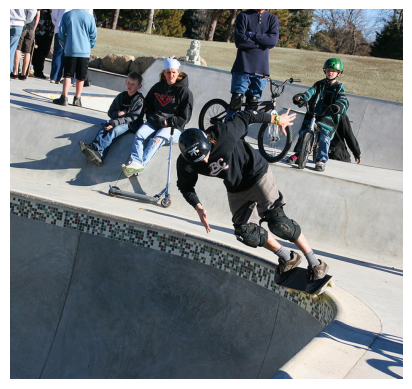

A young man does a trick on a skateboard in a bowl while other children with bikes and scooters watch.
A young man is skate boarding on a ledge with people around.
A person on a skateboard on a ramp.
a person riding a skate board at a skate park
A guy is showing off his skateboarding techniques.


In [2]:
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
%matplotlib inline

# pick a random image and obtain the corresponding URL
ann_id = np.random.choice(ids)
img_id = coco.anns[ann_id]['image_id']
img = coco.loadImgs(img_id)[0]
url = img['coco_url']

# print URL and visualize corresponding image
print(url)
I = io.imread(url)
plt.axis('off')
plt.imshow(I)
plt.show()

# load and display captions
annIds = coco_caps.getAnnIds(imgIds=img['id']);
anns = coco_caps.loadAnns(annIds)
coco_caps.showAnns(anns)

## Step 3: What's to Come!

In this project, you will use the dataset of image-caption pairs to train a CNN-RNN model to automatically generate images from captions.  You'll learn more about how to design the architecture in the next notebook in the sequence (**1_Preliminaries.ipynb**).

![A diagram illustrating an image captioning model. The process begins with an input image, transformed into a tensor and processed by a CNN. The CNN outputs an image feature vector, which is embedded and fed into an LSTM. The LSTM generates a sequence of words by predicting the next word in the sentence, using both the image features and previously generated words. The final output forms the caption: 'A man holding a slice of pizza.'](images/encoder-decoder.png)